# Importing Libraries

In [ ]:
import sys
print(sys.executable)
import sys
!{sys.executable} -m pip install plotly seaborn hdbscan scikit-fuzzy openpyxl


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PowerTransformer,MinMaxScaler
import datetime as dt
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
import hdbscan
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import hdbscan
import skfuzzy as fuzz
import warnings
import datetime as dt
from sklearn.cluster import AgglomerativeClustering
from skfuzzy.cluster import cmeans
import matplotlib.cm as cm  

In [ ]:

warnings.filterwarnings('ignore')

# Exploratory Data Analysis

In [248]:
df = pd.read_excel('Online Retail.xlsx')

In [249]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [250]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


**Insight**  
* There exists missing data in description & CustomerID feature
* Object data --> String Values that must be encoded

In [251]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


**Insight**  
Difference between mean & median in Quantity & UnitPrice features indicating outliers  
Negative Values in Quantity & UnitPrice

## Missing Values  and Null Checking

In [252]:
missing_markers = ['?', '-', 'N/A', 'null', 'nan', 'Empty', ' ', '??','na','Unknown']
for col in df.columns:
    if df[col].dtype == 'object':
        count = df[col].isin(missing_markers).sum()
        if count > 0:
            print(f"Column '{col}' has {count} hidden nulls.")

Column 'Description' has 54 hidden nulls.


In [253]:
df.replace(missing_markers, np.nan, inplace=True)
column_null_counts = df.isna().sum()
column_null_counts

InvoiceNo           0
StockCode           0
Description      1508
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [254]:
total_null_counts = column_null_counts.sum()
total_null_counts

np.int64(136588)

In [255]:
null_percentage = total_null_counts / len(df)
null_percentage

np.float64(0.2520496983810935)

## Zero-Value Transactions

In [256]:
zero_price = df[df['UnitPrice'] == 0]
print(zero_price['Description'].value_counts().head(50))

Description
check                                 159
damages                                45
damaged                                43
found                                  25
sold as set on dotcom                  20
adjustment                             16
Damaged                                14
thrown away                             9
Unsaleable, destroyed.                  9
FRENCH BLUE METAL DOOR SIGN 1           9
amazon                                  8
Found                                   8
FRENCH BLUE METAL DOOR SIGN 8           8
Amazon                                  7
FRENCH BLUE METAL DOOR SIGN 3           7
RECIPE BOX PANTRY YELLOW DESIGN         7
FRENCH BLUE METAL DOOR SIGN No          7
OWL DOORSTOP                            7
FRENCH BLUE METAL DOOR SIGN 4           7
MINT KITCHEN SCALES                     6
FRENCH BLUE METAL DOOR SIGN 5           6
FRENCH BLUE METAL DOOR SIGN 7           6
Manual                                  6
FRENCH BLUE METAL DOOR

**Insight**  
A significant number of entries had a UnitPrice of 0. Analysis: associated descriptions (e.g., 'damages', 'check') confirm these are internal stock adjustments, not sales. Action: removed to prevent skewing Customer Frequency scores with non-commercial activity

## Guest Transactions

In [257]:
null_customer_df = df[df['CustomerID'].isna()]
internal_ops = null_customer_df['Description'].value_counts().head(20)
print("Most common descriptions for missing Customer IDs:")
internal_ops

Most common descriptions for missing Customer IDs:


Description
DOTCOM POSTAGE                        693
JUMBO BAG RED RETROSPOT               497
JUMBO STORAGE BAG SUKI                414
JUMBO SHOPPER VINTAGE RED PAISLEY     388
JUMBO BAG WOODLAND ANIMALS            372
JUMBO BAG PINK POLKADOT               348
RECYCLING BAG RETROSPOT               341
RED TOADSTOOL LED NIGHT LIGHT         328
SUKI  SHOULDER BAG                    326
GREEN REGENCY TEACUP AND SAUCER       324
PARTY BUNTING                         311
PACK OF 72 RETROSPOT CAKE CASES       305
WOODLAND CHARLOTTE BAG                304
RED RETROSPOT CHARLOTTE BAG           301
CHARLOTTE BAG SUKI DESIGN             300
WHITE HANGING HEART T-LIGHT HOLDER    299
REGENCY CAKESTAND 3 TIER              295
JAM MAKING SET PRINTED                294
RECIPE BOX PANTRY YELLOW DESIGN       290
JUMBO  BAG BAROQUE BLACK WHITE        287
Name: count, dtype: int64

**Insight**  
Data integrity analysis reveals a significant volume of transactions with missing Customer IDs. While a portion of these represents internal operational adjustments (e.g., stock checks, damages), the majority are valid 'Guest Checkouts' where customers purchased items without logging in. Although these transactions contribute to total revenue, they must be excluded from Customer Segmentation (K-Means/RFM) analysis as they cannot be attributed to specific user profiles, preventing distinct behavioral tracking.

## Non-Customer Product Transaction

In [ ]:
non_product_codes = [
    'POST',          # Postage
    'DOT',           # Dotcom Postag
    'M',             # Manual
    'S',             # Samples
    'BANK CHARGES',    
    'AMAZONFEE',
    'CRUK',
    'C2',            # Carriage
    'PADS'

]

internal_ops_df = df[df['StockCode'].isin(non_product_codes)]

print(f"Total Internal Operations Rows (Based on StockCode): {len(internal_ops_df)}")

print("-" * 30)
print(internal_ops_df[['StockCode', 'Description', 'CustomerID', 'UnitPrice']].head(10))

Total Internal Operations Rows (Based on StockCode): 2835
------------------------------
         StockCode     Description  CustomerID  UnitPrice
45            POST         POSTAGE     12583.0      18.00
386           POST         POSTAGE     12791.0      15.00
1123          POST         POSTAGE     12662.0      18.00
1423            C2        CARRIAGE     14911.0      50.00
1814           DOT  DOTCOM POSTAGE         NaN     569.77
2239             M          Manual     16274.0       1.25
2250             M          Manual     16274.0      18.95
3041           DOT  DOTCOM POSTAGE         NaN     607.49
4406  BANK CHARGES    Bank Charges     15823.0      15.00
5073          POST         POSTAGE     12738.0      18.00


**Insight**  
The analysis identified 2,835 non-product transactions, primarily consisting of Postage ('POST'), Manual Adjustments ('M'), and Bank Charges. While standard postage is linked to customers, entries like 'DOTCOM POSTAGE' appear as high-value internal costs with no associated Customer ID. To ensure the clustering model reflects actual product preferences rather than operational fees, these rows must be excluded from the dataset.

## Duplicated Values Checking

In [259]:
duplicates_count = df.duplicated().sum()
duplicates_count

np.int64(5268)

## Data Visualization before Preprocessing

### Distribution of Quantity & UnitPrice

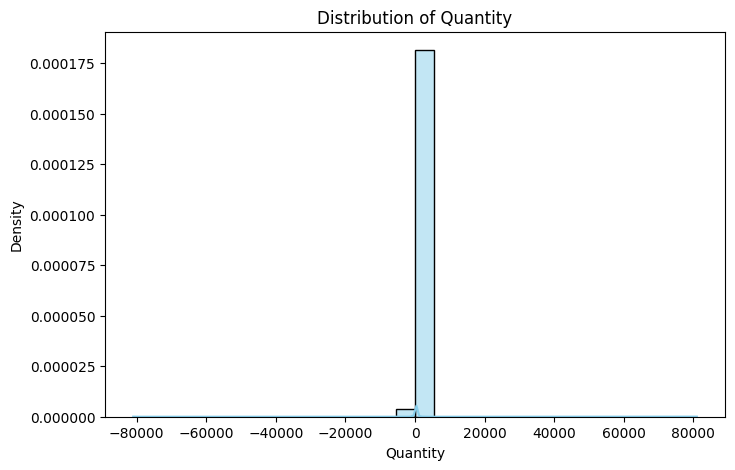

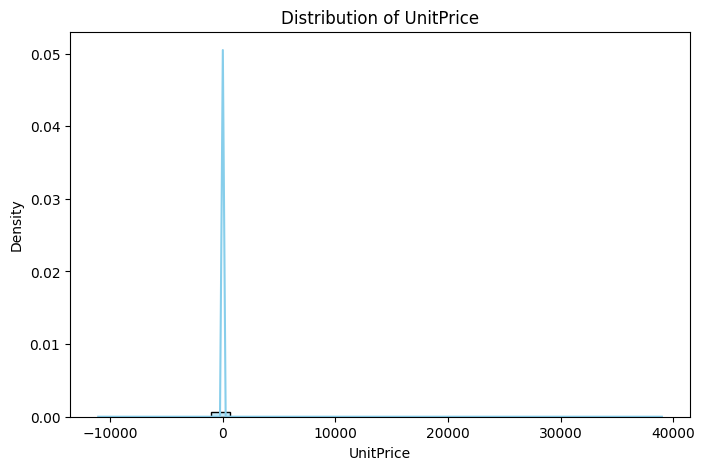

In [260]:
numeric_cols = ['Quantity', 'UnitPrice']

for col in numeric_cols:
    col_data = df[col].dropna()

    if len(col_data) > 1:
        bin_size = (col_data.max() - col_data.min()) / 30
        bins = int(np.ceil((col_data.max() - col_data.min()) / bin_size))
    else:
        bins = 10
    
    plt.figure(figsize=(8,5))
    
 
    sns.histplot(col_data, bins=bins, kde=True, color='skyblue', stat="density")
    
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.show()

### Boxplot of Quantity & UnitPrice

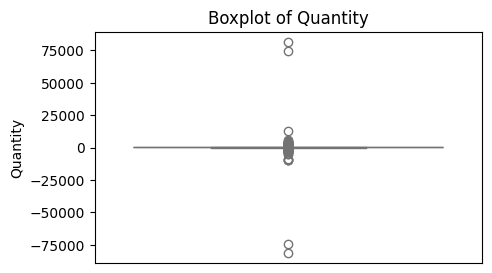

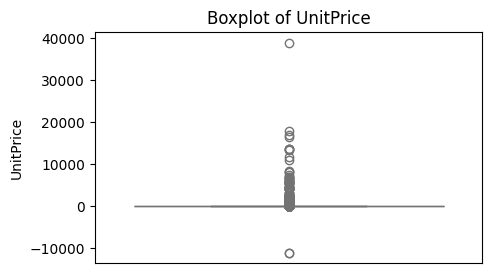

In [261]:
numeric_cols = ['Quantity', 'UnitPrice']

for col in numeric_cols:
    plt.figure(figsize=(5,3))  
    
    sns.boxplot(y=df[col], color='lightgreen')
    
    plt.title(f"Boxplot of {col}", fontsize=12)
    plt.ylabel(col)
    plt.xticks([])  
    plt.show()

## Which country dominates the customer base?

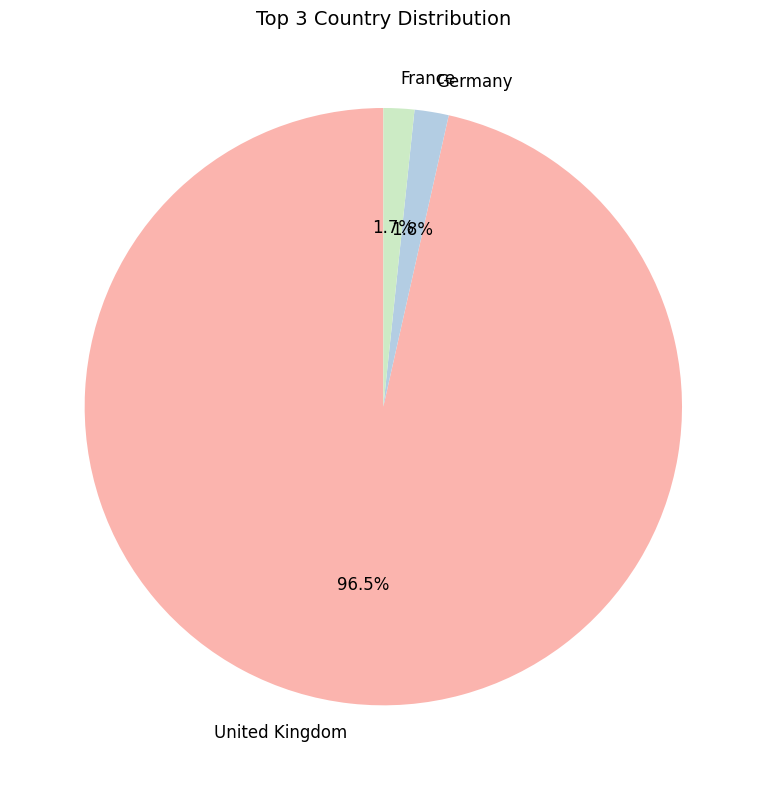

In [262]:

country_counts = df['Country'].value_counts()

top_10_countries = country_counts.head(3)


plt.figure(figsize=(8,8))
plt.pie(
    top_10_countries.values,
    labels=top_10_countries.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=plt.cm.Pastel1.colors,
    textprops={'fontsize': 12}
)
plt.title("Top 3 Country Distribution", fontsize=14)
plt.tight_layout()
plt.show()


**Insight**  
The dataset is heavily skewed towards the United Kingdom, which accounts for approximately 96.5% of the total transactions. The remaining countries collectively represent less than 4% of the data, indicating a significant geographic imbalance in the customer base.

## Retention: One-time vs. Repeat Buyers

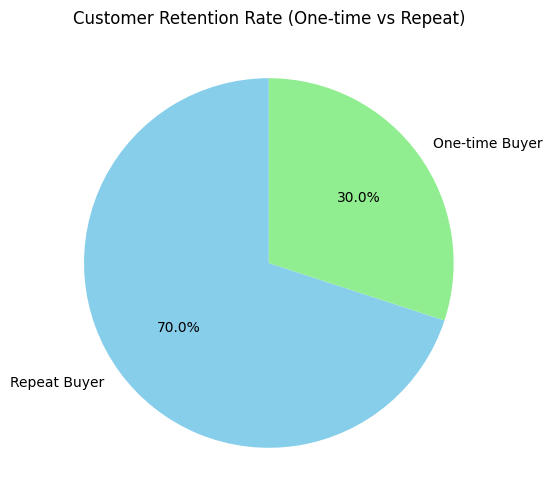

In [263]:

customer_freq = df.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()
customer_freq['Type'] = customer_freq['InvoiceNo'].apply(lambda x: 'One-time Buyer' if x == 1 else 'Repeat Buyer')


type_counts = customer_freq['Type'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    type_counts.values,
    labels=type_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['skyblue', 'lightgreen']
)
plt.title('Customer Retention Rate (One-time vs Repeat)')
plt.show()


**Insight**  
The analysis demonstrates an impressive customer retention rate. With 70% of the customer base classified as Repeat Buyers, the business exhibits strong customer loyalty. This indicates high satisfaction levels, as most customers prefer to continue transacting with the company rather than churning after a single purchase.

## Scatter Plot of Quantity & UnitPrice

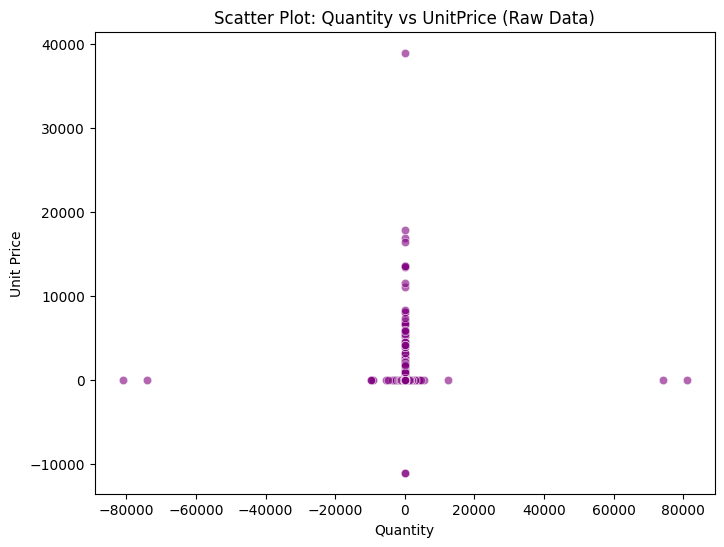

In [264]:

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='Quantity',
    y='UnitPrice',
    color='purple', 
    alpha=0.6       
)
plt.title("Scatter Plot: Quantity vs UnitPrice (Raw Data)")
plt.xlabel("Quantity")
plt.ylabel("Unit Price")
plt.show()


**Insight**  
 * No Linear Relationship between Quantity & UnitPrice
 * Extreme Negative Values & Outliers

# Preprocessing

## Handling Missing Values

In [265]:
print("Original shape:", df.shape)
df = df.dropna(subset=['CustomerID'])
df = df.dropna(subset=['Description'])
print("Original shape:", df.shape)

Original shape: (541909, 8)
Original shape: (406829, 8)


## Handling Duplicates

In [266]:
df = df.drop_duplicates()
print("Original shape:", df.shape)

Original shape: (401604, 8)


## Feature Engineering

## Remove Negative Values

In [267]:
df_temp = df.copy()
df_temp = df_temp[df_temp['Quantity'] > 0]
df_temp = df_temp[df_temp['UnitPrice'] > 0]

df_temp['TotalPrice'] = df_temp['Quantity']  * df_temp['UnitPrice']

In [268]:
df_temp.shape

(392692, 9)

## Handling Non-Customer Product Transaction

In [269]:
operational_codes = ['POST', 'M', 'C2', 'DOT', 'BANK CHARGES', 'D', 'S', 'CRUK']

df_temp = df_temp[~df_temp['StockCode'].isin(operational_codes)]
print("Copy Original shape:", df_temp.shape)
df = df[~df['StockCode'].isin(operational_codes)]
print("Original shape:", df.shape)

Copy Original shape: (391153, 9)
Original shape: (399693, 8)


# Visualizations after Preprocessing

## Boxplot of Quantity, UnitPrice & TotalPrice

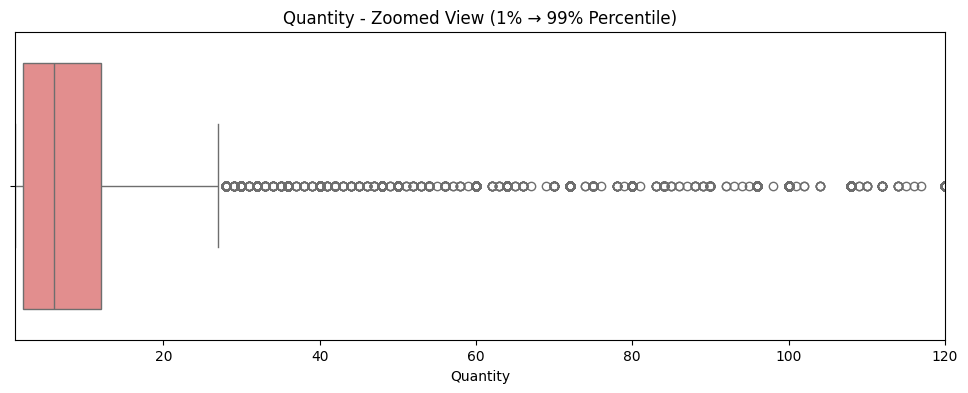

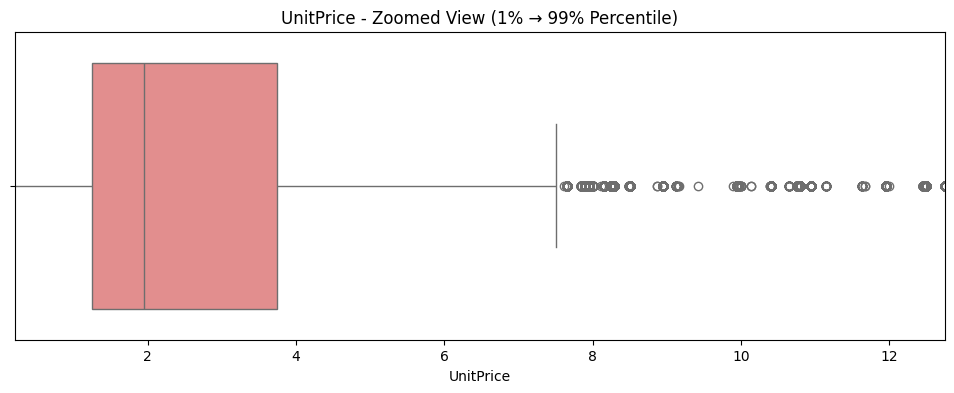

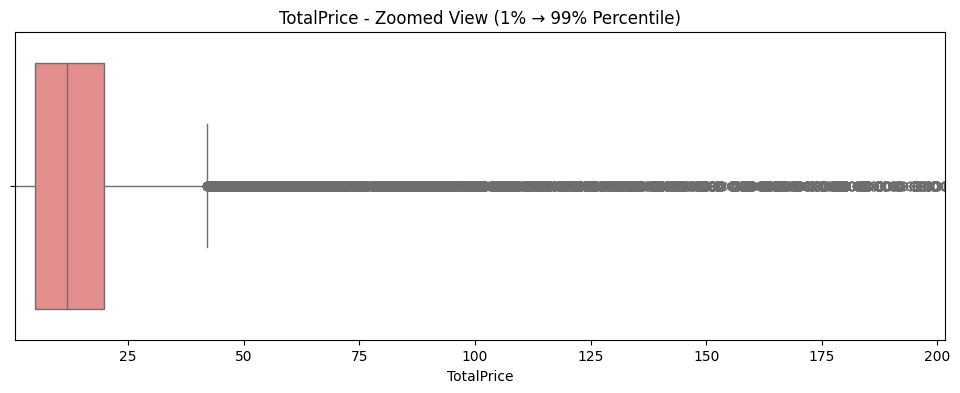

Original shape: (391153, 9)


In [270]:

cols_to_plot = ['Quantity', 'UnitPrice', 'TotalPrice']

for col in cols_to_plot:

    q1 = df_temp[col].quantile(0.01)
    q99 = df_temp[col].quantile(0.99)
    
    plt.figure(figsize=(12,4))
    sns.boxplot(x=df_temp[col], color='lightcoral')
    

    plt.xlim(q1, q99)
    
    plt.title(f"{col} - Zoomed View (1% → 99% Percentile)")
    plt.xlabel(col)
    plt.show()

print("Original shape:", df_temp.shape)


## Distribution of Quantity, UnitPrice & TotalPrice

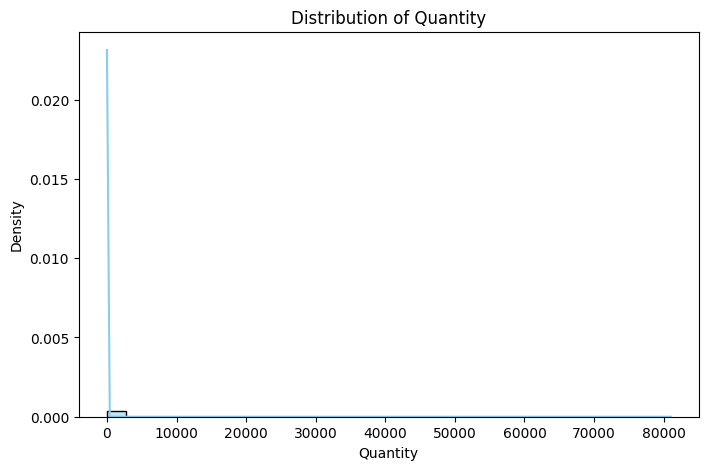

Original shape: (391153, 9)


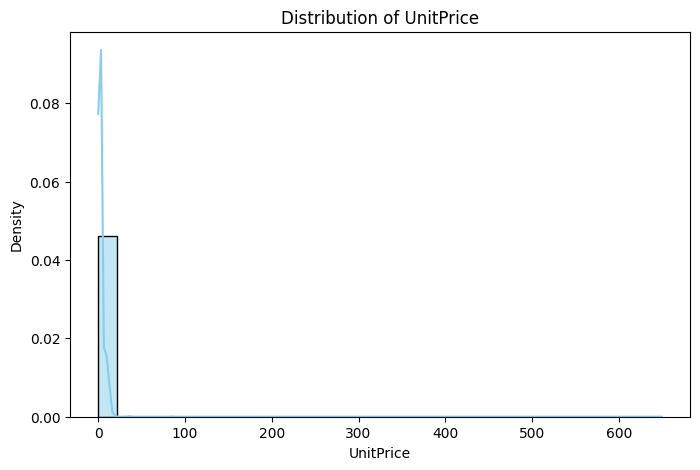

Original shape: (391153, 9)


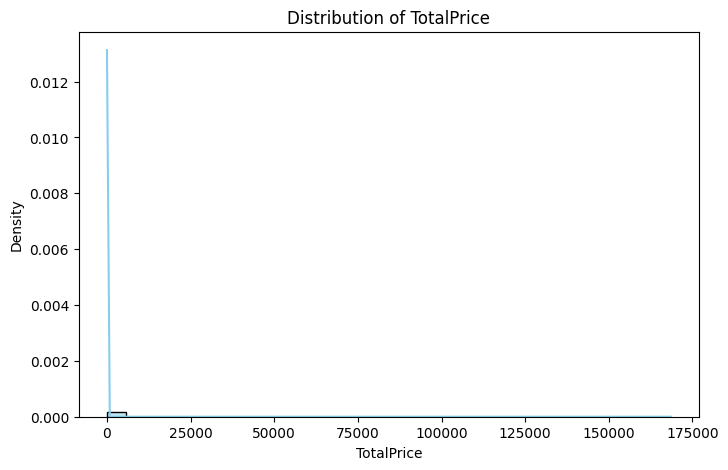

Original shape: (391153, 9)


In [271]:

numeric_cols = ['Quantity', 'UnitPrice','TotalPrice']

for col in numeric_cols:
    col_data = df_temp[col].dropna()
 
    if len(col_data) > 1:
        bin_size = (col_data.max() - col_data.min()) / 30
        bins = int(np.ceil((col_data.max() - col_data.min()) / bin_size))
    else:
        bins = 10
    
    plt.figure(figsize=(8,5))
    sns.histplot(col_data, bins=bins, kde=True, color='skyblue', stat="density")
    
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.show()
    
    print("Original shape:", df_temp.shape)


## Temporal Analysis

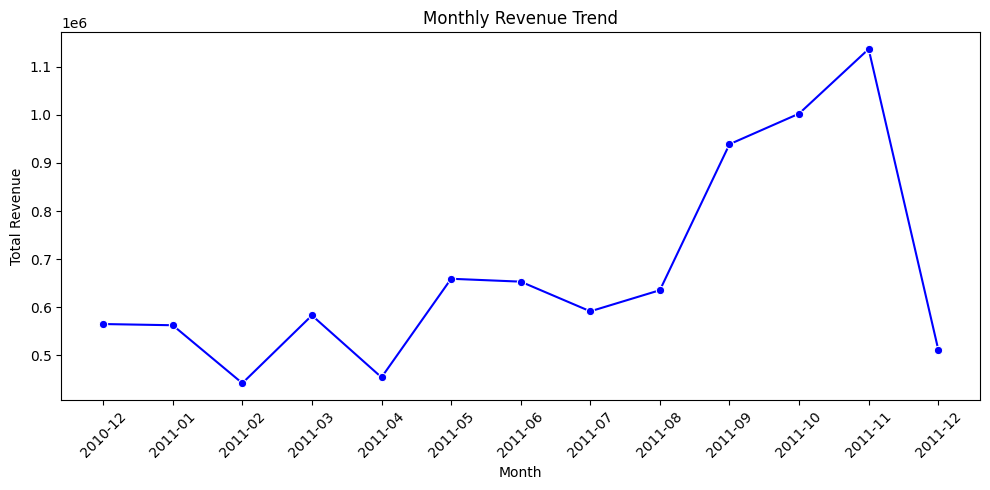

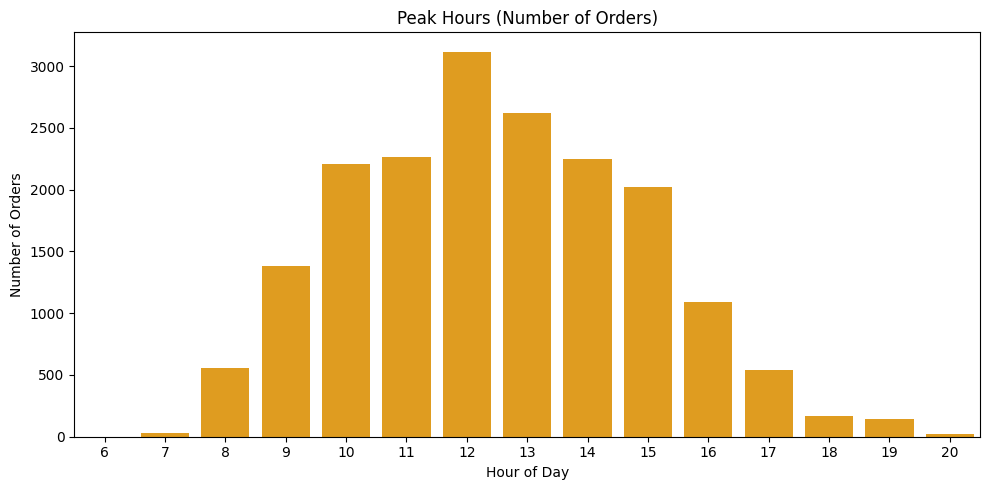

In [272]:

df_temp['InvoiceDate'] = pd.to_datetime(df_temp['InvoiceDate'])
df_temp['Month'] = df_temp['InvoiceDate'].dt.to_period('M').astype(str)
df_temp['Day'] = df_temp['InvoiceDate'].dt.day_name()
df_temp['Hour'] = df_temp['InvoiceDate'].dt.hour

monthly_sales = df_temp.groupby('Month')['TotalPrice'].sum().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=monthly_sales, x='Month', y='TotalPrice', marker='o', color='blue')
plt.xticks(rotation=45)
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.tight_layout()
plt.show()

hourly_sales = df_temp.groupby('Hour')['InvoiceNo'].nunique().reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=hourly_sales, x='Hour', y='InvoiceNo', color='orange')
plt.title('Peak Hours (Number of Orders)')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()



**Insight**  
The analysis reveals that November is the most profitable month, likely due to seasonal trends. On a daily basis, customer activity peaks at 12:00 PM, indicating a preference for midday shopping. This suggests marketing efforts should target the Q4 season and midday time slots for maximum impact.

## Top 10 Customers by TotalPrice

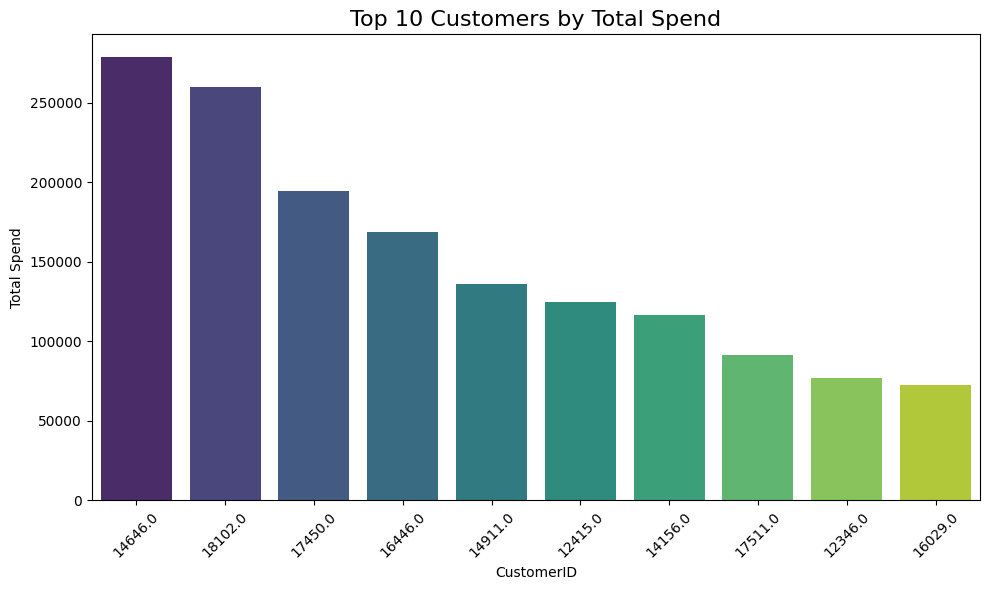

In [273]:

top_customers = df_temp.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False).head(10)
customer_ids_str = top_customers.index.astype(str)

plt.figure(figsize=(10,6))
sns.barplot(x=customer_ids_str, y=top_customers.values, palette='viridis')

plt.title('Top 10 Customers by Total Spend', fontsize=16)
plt.xlabel('CustomerID')
plt.ylabel('Total Spend')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()




# Constructiong RFM

In [274]:

print(df_temp.shape)

snapshot_date = df_temp['InvoiceDate'].max() + dt.timedelta(days=1)
rfm = df_temp.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

rfm.rename(columns={'InvoiceDate': 'Recency',
                    'InvoiceNo': 'Frequency',
                    'TotalPrice': 'Monetary'}, inplace=True)

rfm.head()

(391153, 12)


,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1437.24
12349.0,19,1,1457.55
12350.0,310,1,294.40


In [275]:
print("Customer-level data head:")
print(rfm.shape)
print(df_temp.shape)
print(rfm.isnull().sum())
print(rfm.duplicated().sum())
print(rfm.columns.tolist())


Customer-level data head:
(4334, 3)
(391153, 12)
Recency      0
Frequency    0
Monetary     0
dtype: int64
0
['Recency', 'Frequency', 'Monetary']


## Scaling RFM DataFrame

In [276]:

pt = PowerTransformer(method='yeo-johnson')
rfm_log = pt.fit_transform(rfm)
scaler = MinMaxScaler()
rfm_scaled = scaler.fit_transform(rfm_log)
rfm_scaled_df = pd.DataFrame(rfm_scaled, index=rfm.index, columns=rfm.columns)
rfm_scaled_df.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,0.963495,0.000000,0.927097
12347.0,0.054153,0.675095,0.729450
12348.0,0.614886,0.520807,0.639776
12349.0,0.352415,0.000000,0.640978
12350.0,0.950297,0.000000,0.493923


In [277]:
print("Customer-level data head:")
print(rfm_scaled_df.shape)
print(rfm_scaled_df.isnull().sum())
print(rfm_scaled_df.duplicated().sum())
print(rfm_scaled_df.columns.tolist())

Customer-level data head:
(4334, 3)
Recency      0
Frequency    0
Monetary     0
dtype: int64
0
['Recency', 'Frequency', 'Monetary']


# RFM Data Visualization

## RFM Data Scatter Plot

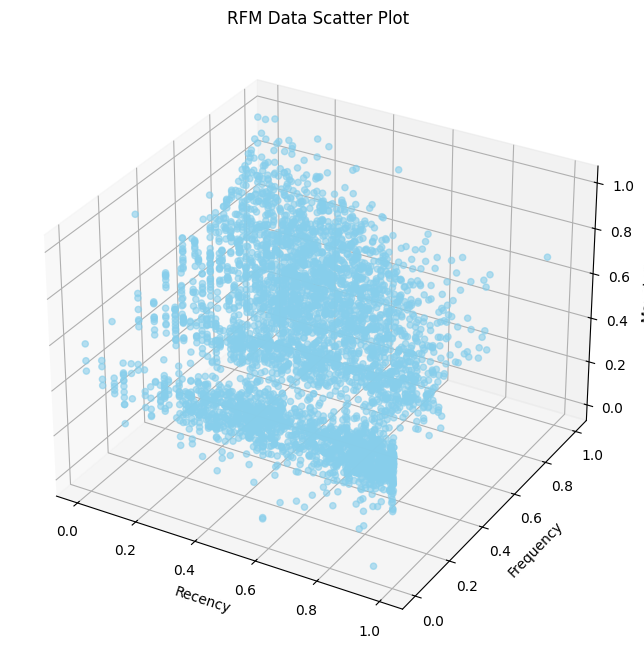

In [278]:

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    rfm_scaled_df['Recency'],
    rfm_scaled_df['Frequency'],
    rfm_scaled_df['Monetary'],
    s=20, 
    c='skyblue', 
    alpha=0.6
)

ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')
ax.set_title('RFM Data Scatter Plot')

plt.show()


## RFM Data Box  Plot

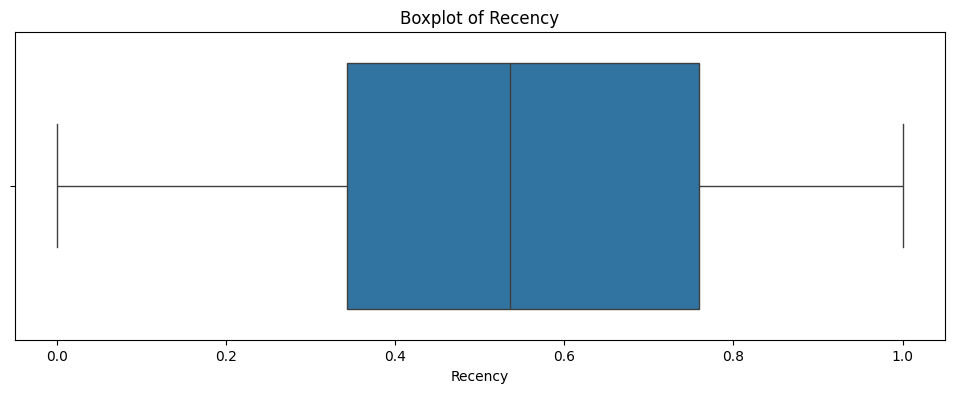

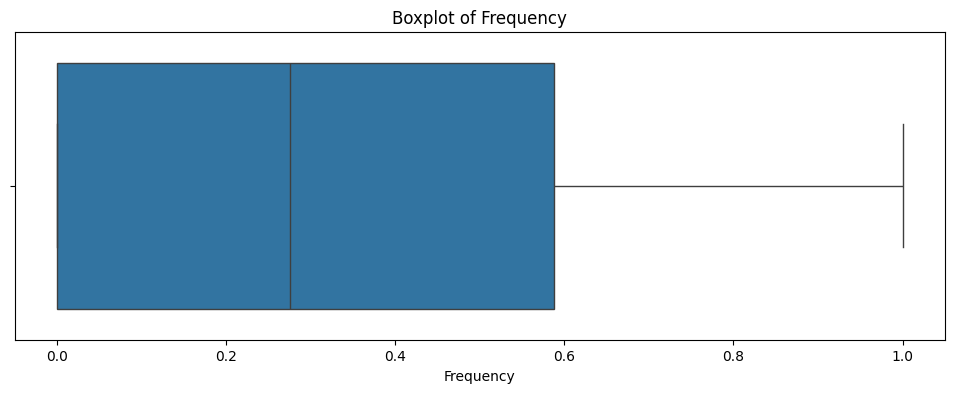

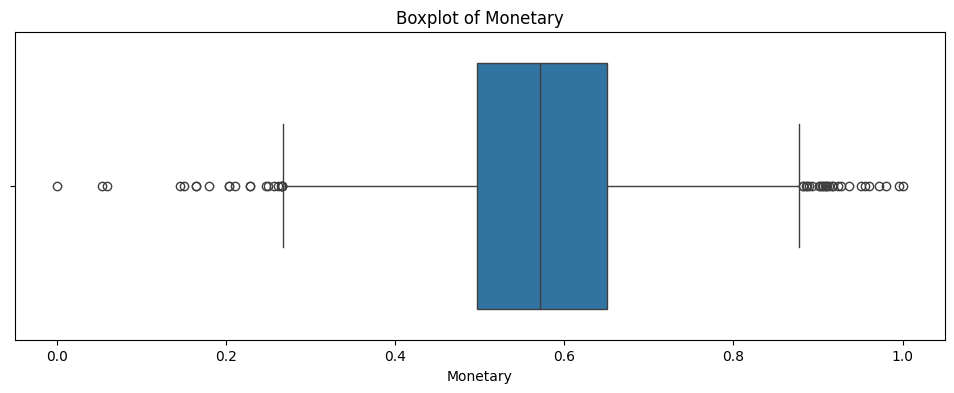

In [279]:
plt.figure(figsize=(12,4))
sns.boxplot(x=rfm_scaled_df['Recency'])
plt.title('Boxplot of Recency')
plt.show()

plt.figure(figsize=(12,4))

sns.boxplot(x=rfm_scaled_df['Frequency'])
plt.title('Boxplot of Frequency')
plt.show()
plt.figure(figsize=(12,4))

sns.boxplot(x=rfm_scaled_df['Monetary'])
plt.title('Boxplot of Monetary')
plt.show()


## RFM Checking Negatative  and null Values    

In [280]:
rfm_scaled_df[rfm_scaled_df['Recency'] < 0].shape
rfm_scaled_df[rfm_scaled_df['Frequency'] < 0]
rfm_scaled_df[rfm_scaled_df['Monetary'] < 0]
rfm_scaled_df.isna().sum()


Recency      0
Frequency    0
Monetary     0
dtype: int64

## RFM  Distribution

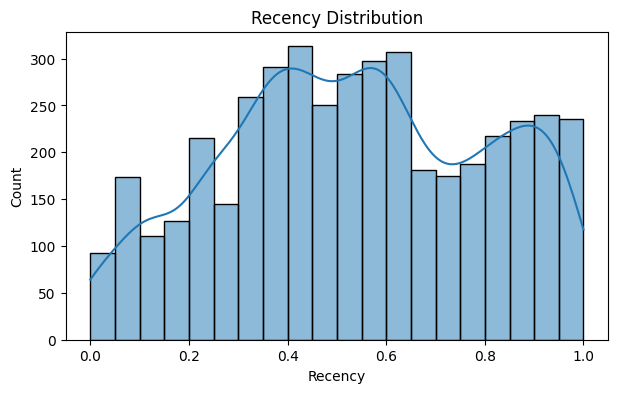

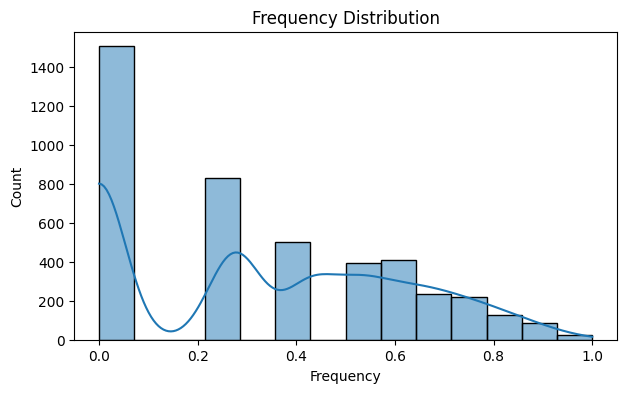

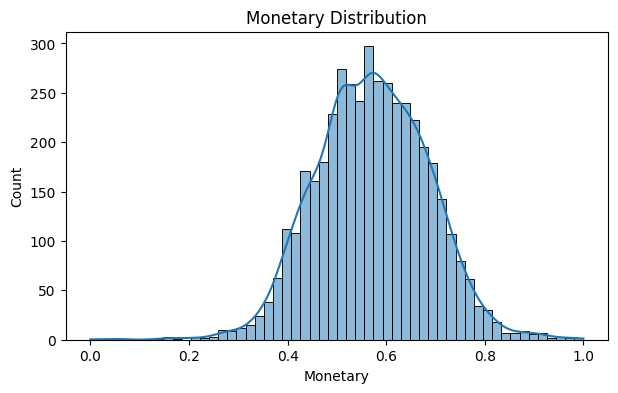

In [281]:
plt.figure(figsize=(7,4))
sns.histplot(rfm_scaled_df['Recency'], kde=True)
plt.title("Recency Distribution")
plt.show()
plt.figure(figsize=(7,4))
sns.histplot(rfm_scaled_df['Frequency'], kde=True)
plt.title("Frequency Distribution")
plt.show()
plt.figure(figsize=(7,4))
sns.histplot(rfm_scaled_df['Monetary'], kde=True)
plt.title("Monetary Distribution")
plt.show()


## Adding  New Features for PCA Scenario

In [282]:

rfm_features_PCA = rfm.copy()

risk_qty_components_df = df.groupby('CustomerID').agg(
    Total_Qty_Bought=('Quantity', lambda x: x[x > 0].sum()),        
    Total_Qty_Returned=('Quantity', lambda x: x[x < 0].sum()),       
    Total_Unique_Invoices=('InvoiceNo', 'nunique'),                  
    Cancelled_Invoices_Count=('InvoiceNo', lambda x: x[x.astype(str).str.upper().str.contains('C')].nunique()), # عدد الفواتير الملغاة الفريدة
).reset_index()


risk_qty_components_df['ReturnRate'] = (
    risk_qty_components_df['Total_Qty_Returned'].abs() /
    risk_qty_components_df['Total_Qty_Bought']
).fillna(0).clip(upper=1.0)
rfm_features_PCA = rfm_features_PCA.merge(
    risk_qty_components_df[['CustomerID', 'Total_Qty_Bought', 'Total_Qty_Returned', 'Total_Unique_Invoices', 'Cancelled_Invoices_Count', 'ReturnRate']],
    on='CustomerID',
    how='left'
)


advanced_features_temp = df_temp.groupby('CustomerID').agg(

    Tenure=('InvoiceDate', lambda x: (x.max() - x.min()).days + 1),  
    Unique_Products=('StockCode', 'nunique'),                         
).reset_index()


rfm_features_PCA = rfm_features_PCA.merge(advanced_features_temp, on='CustomerID', how='left')


rfm_features_PCA['Avg_Days_Between_Purchases'] = np.where(
    rfm_features_PCA['Total_Unique_Invoices'] > 1,
    rfm_features_PCA['Tenure'] / (rfm_features_PCA['Total_Unique_Invoices'] - 1),
    0)

rfm_features_PCA['CancellationRate'] = (
    rfm_features_PCA['Cancelled_Invoices_Count'] / rfm_features_PCA['Total_Unique_Invoices']
).fillna(0).clip(upper=1.0)


features_to_drop = ['Total_Qty_Bought', 'Total_Qty_Returned', 'Total_Unique_Invoices', 'Cancelled_Invoices_Count']
rfm_features_PCA.drop(columns=features_to_drop, inplace=True, errors='ignore')


rfm_features_PCA.fillna(0, inplace=True)


final_columns_order = [
    'CustomerID',
    'Recency', 'Frequency', 'Monetary', 'ReturnRate', 
    'Tenure', 'Avg_Days_Between_Purchases', 'Unique_Products', 'CancellationRate'
]

rfm_features_PCA = rfm_features_PCA[[col for col in final_columns_order if col in rfm_features_PCA.columns]]


print("\n--- Final rfm_features_PCA Head (Retained Order + Corrected Features) ---")
print(rfm_features_PCA.head())


--- Final rfm_features_PCA Head (Retained Order + Corrected Features) ---
   CustomerID  Recency  Frequency  Monetary  ReturnRate  Tenure  \
0     12346.0      326          1  77183.60         1.0       1   
1     12347.0        2          7   4310.00         0.0     366   
2     12348.0       75          4   1437.24         0.0     283   
3     12349.0       19          1   1457.55         0.0       1   
4     12350.0      310          1    294.40         0.0       1   

   Avg_Days_Between_Purchases  Unique_Products  CancellationRate  
0                    1.000000                1               0.5  
1                   61.000000              103               0.0  
2                   94.333333               21               0.0  
3                    0.000000               72               0.0  
4                    0.000000               16               0.0  


## RFM with New Features Preprocessing

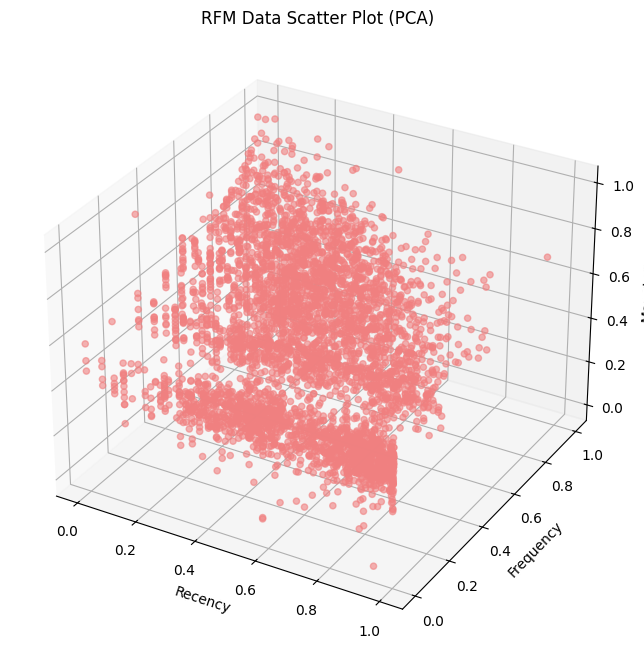

In [283]:

features = [

    'Recency', 'Frequency', 'Monetary', 'ReturnRate', 
    'Tenure', 'Avg_Days_Between_Purchases', 'Unique_Products', 'CancellationRate' 
]


pt = PowerTransformer(method='yeo-johnson')
rfm_pt_PCA = pt.fit_transform(rfm_features_PCA[features])


scaler = MinMaxScaler()
rfm_scaled_PCA = scaler.fit_transform(rfm_pt_PCA)

rfm_scaled_df_PCA = pd.DataFrame(rfm_scaled_PCA, columns=features, index=rfm_features_PCA['CustomerID'])
rfm_scaled_df_PCA.head()


fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    rfm_scaled_df_PCA['Recency'],
    rfm_scaled_df_PCA['Frequency'],
    rfm_scaled_df_PCA['Monetary'],
    s=20,       
    c='lightcoral',  
    alpha=0.6
)

ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')
ax.set_title('RFM Data Scatter Plot (PCA)')

plt.show()


## Calculate the Variance Percentage of PC Components

PC1: 0.5547 (0.5547 cumulative)
PC2: 0.2721 (0.8268 cumulative)
PC3: 0.0775 (0.9042 cumulative)
PC4: 0.0399 (0.9441 cumulative)
PC5: 0.0303 (0.9744 cumulative)
PC6: 0.0172 (0.9916 cumulative)
PC7: 0.0049 (0.9965 cumulative)
PC8: 0.0035 (1.0000 cumulative)


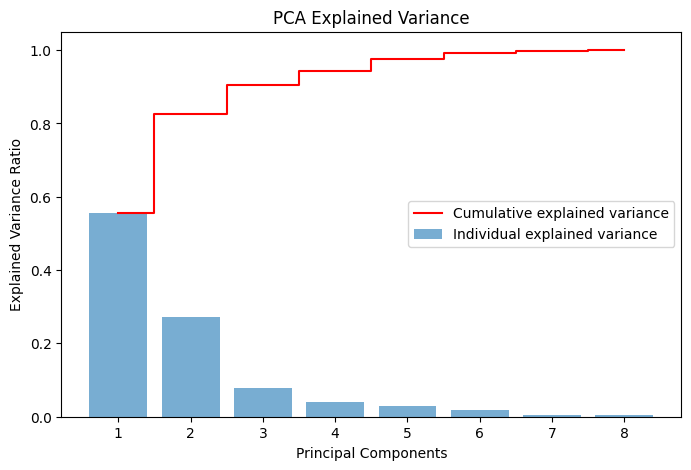

In [284]:

X = rfm_scaled_df_PCA.values


pca = PCA()
pca_result = pca.fit_transform(X)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

for i, var in enumerate(explained_variance):
    print(f"PC{i+1}: {var:.4f} ({cumulative_variance[i]:.4f} cumulative)")

plt.figure(figsize=(8,5))
plt.bar(range(1,len(explained_variance)+1), explained_variance, alpha=0.6, label='Individual explained variance')
plt.step(range(1,len(cumulative_variance)+1), cumulative_variance, where='mid', label='Cumulative explained variance', color='red')
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA Explained Variance')
plt.legend()
plt.show()


## Choosing Best PCA Components

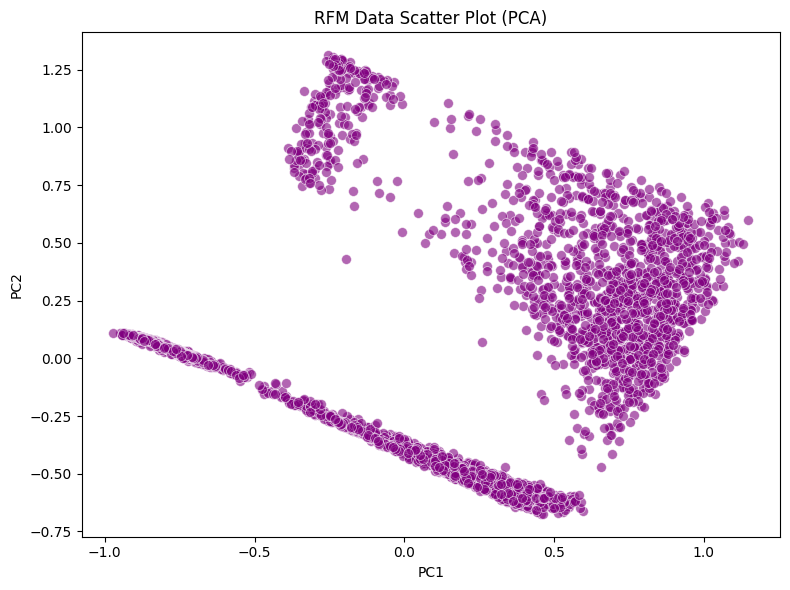

In [285]:

pca_n = PCA(n_components=2)
pca_result_n = pca_n.fit_transform(rfm_scaled_df_PCA.values)

pca_df = pd.DataFrame(pca_result_n, index=rfm_scaled_df_PCA.index, columns=[f'PC{i+1}' for i in range(pca_result_n.shape[1])])
pca_df.head()

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    color='purple', 
    s=50,            
    alpha=0.6
)

plt.title("RFM Data Scatter Plot (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()


# K-Means Algorithm

## K-Means on RFM Data

### Elbow Method to determine Optimal K

K=2: Silhouette Score = 0.4595
K=3: Silhouette Score = 0.3918
K=4: Silhouette Score = 0.3899
K=5: Silhouette Score = 0.3930
K=6: Silhouette Score = 0.3627
K=7: Silhouette Score = 0.3785
K=8: Silhouette Score = 0.3790
K=9: Silhouette Score = 0.3849
K=10: Silhouette Score = 0.3721


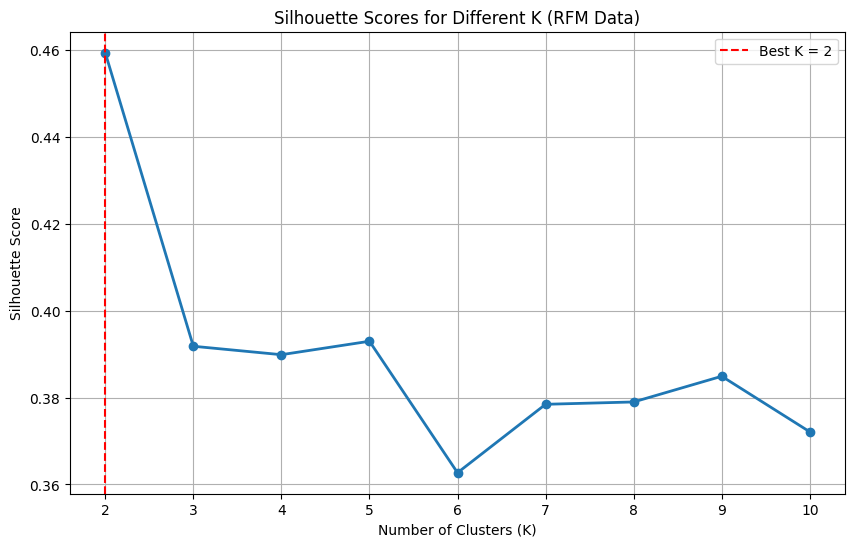


BEST NUMBER OF CLUSTERS = 2



In [286]:
silhouette_scores = []
range_n_clusters = range(2, 11)
rfm_kmeans = rfm_scaled_df.copy()
for k in range_n_clusters:

    kmeans_temp = KMeans(n_clusters=k, init='k-means++', random_state=42)
    labels = kmeans_temp.fit_predict(rfm_kmeans)
    score = silhouette_score(rfm_kmeans, labels)
    silhouette_scores.append(score)
    print(f"K={k}: Silhouette Score = {score:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(range_n_clusters, silhouette_scores, marker='o', linewidth=2)
plt.title('Silhouette Scores for Different K (RFM Data)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)

best_k = range_n_clusters[silhouette_scores.index(max(silhouette_scores))]
plt.axvline(x=best_k, color='r', linestyle='--', label=f'Best K = {best_k}')
plt.legend()
plt.show()
print(f"\nBEST NUMBER OF CLUSTERS = {best_k}\n")

### Applying the Algorithm

In [287]:
optimal_k = 3

clustered_rfm_df = rfm_scaled_df.copy()
kmeans = KMeans(n_clusters=optimal_k, random_state = 42, n_init=10, init = 'k-means++')
clustered_rfm_df['Cluster_Labels'] = kmeans.fit_predict(rfm_scaled_df)

print(clustered_rfm_df['Cluster_Labels'].value_counts())

Cluster_Labels
1    1719
0    1505
2    1110
Name: count, dtype: int64


In [288]:
cluster_analysis = clustered_rfm_df.groupby('Cluster_Labels').mean()

print(cluster_analysis)

                 Recency  Frequency  Monetary
Cluster_Labels                               
0               0.524357   0.404138  0.586788
1               0.734476   0.040130  0.483870
2               0.243719   0.677120  0.687828


### Cluster Evaluation

In [289]:
score = silhouette_score(rfm_scaled_df, clustered_rfm_df['Cluster_Labels'], random_state=42)

print(f'Silhouette Score (Sampled): {score:.2f}')

Silhouette Score (Sampled): 0.37


### Cluster Visualization

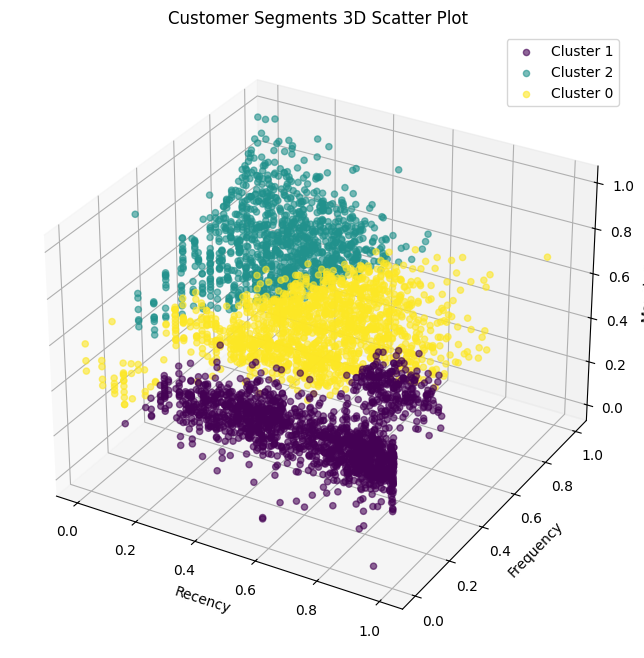

In [290]:


fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')


clusters = clustered_rfm_df['Cluster_Labels'].unique()
colors = cm.viridis(np.linspace(0, 1, len(clusters)))  
for cluster, color in zip(clusters, colors):
    cluster_data = clustered_rfm_df[clustered_rfm_df['Cluster_Labels'] == cluster]
    ax.scatter(
        cluster_data['Recency'],
        cluster_data['Frequency'],
        cluster_data['Monetary'],
        s=20,
        color=color,
        alpha=0.6,
        label=f'Cluster {cluster}'
    )

ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')
ax.set_title('Customer Segments 3D Scatter Plot')
ax.legend()
plt.show()


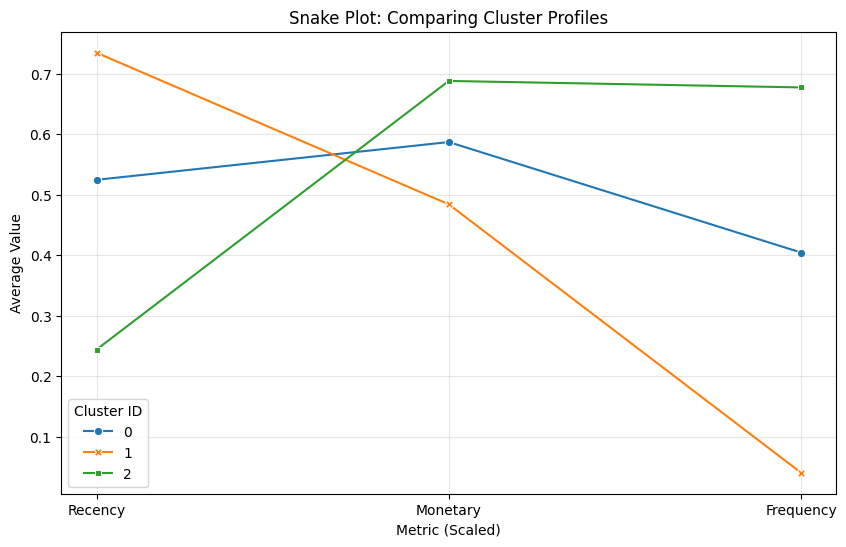

In [291]:
cluster_avg = clustered_rfm_df.groupby('Cluster_Labels')[['Recency', 'Monetary','Frequency']].mean()


plt.figure(figsize=(10, 6))

sns.lineplot(data=cluster_avg.T, markers=True, dashes=False)

plt.title('Snake Plot: Comparing Cluster Profiles')
plt.xlabel('Metric (Scaled)')
plt.ylabel('Average Value')
plt.legend(title='Cluster ID')
plt.grid(True, alpha=0.3)

## K-Means on PCA Data

### Elbow Method

K=2: Silhouette Score = 0.4913
K=3: Silhouette Score = 0.6508
K=4: Silhouette Score = 0.7078
K=5: Silhouette Score = 0.6531
K=6: Silhouette Score = 0.6241
K=7: Silhouette Score = 0.6260
K=8: Silhouette Score = 0.6242
K=9: Silhouette Score = 0.5942
K=10: Silhouette Score = 0.5851


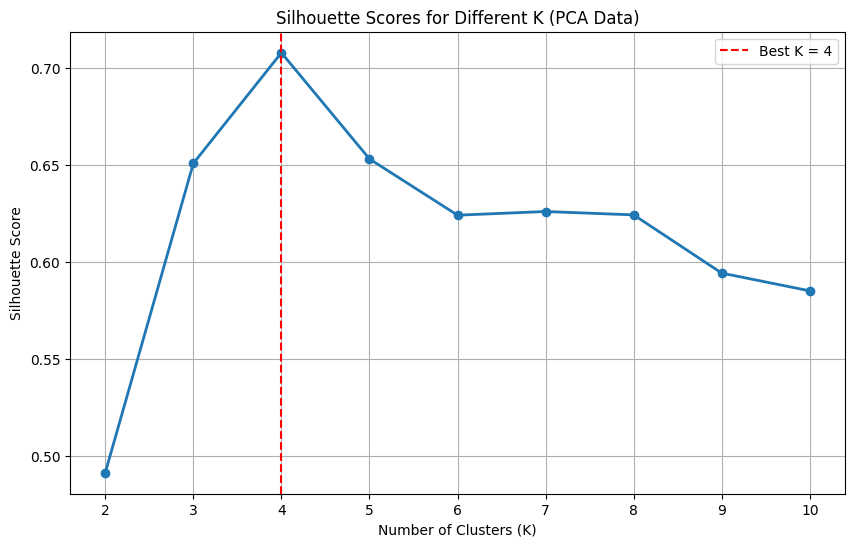


BEST NUMBER OF CLUSTERS = 4



In [292]:
silhouette_scores = []
range_n_clusters = range(2, 11)

pca_kmeans = pca_df.copy()
for k in range_n_clusters:

    kmeans_temp = KMeans(n_clusters=k, init='k-means++', random_state=42)
    labels = kmeans_temp.fit_predict(pca_kmeans)
    score = silhouette_score(pca_kmeans, labels)
    silhouette_scores.append(score)
    print(f"K={k}: Silhouette Score = {score:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(range_n_clusters, silhouette_scores, marker='o', linewidth=2)
plt.title('Silhouette Scores for Different K (PCA Data)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)

best_k = range_n_clusters[silhouette_scores.index(max(silhouette_scores))]
plt.axvline(x=best_k, color='r', linestyle='--', label=f'Best K = {best_k}')
plt.legend()
plt.show()
print(f"\nBEST NUMBER OF CLUSTERS = {best_k}\n")

### Applying the Algorithm

In [293]:

kmeans_final = KMeans(n_clusters=best_k, init='k-means++', random_state=42)
final_labels = kmeans_final.fit_predict(pca_df)

### Cluster Evaluation

In [294]:
pca_kmeans['Cluster'] = final_labels
final_silhouette = silhouette_score(pca_df, final_labels)
print(f"Final Silhouette Score = {final_silhouette:.4f}")

Final Silhouette Score = 0.7078


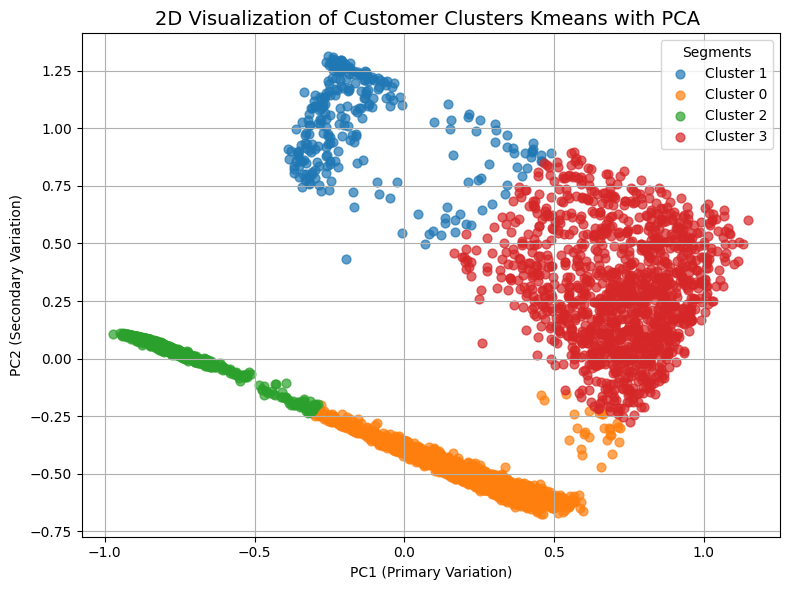

In [295]:
plot_df = pca_df.copy()
plot_df['Cluster'] = final_labels

plt.figure(figsize=(8, 6))

clusters = plot_df['Cluster'].unique()

for cluster in clusters:
    cluster_data = plot_df[plot_df['Cluster'] == cluster]
    
    plt.scatter(
        cluster_data['PC1'],
        cluster_data['PC2'],
        s=40,
        alpha=0.7,
        label=f'Cluster {cluster}'
    )

plt.title('2D Visualization of Customer Clusters Kmeans with PCA ', fontsize=14)
plt.xlabel('PC1 (Primary Variation)')
plt.ylabel('PC2 (Secondary Variation)')
plt.legend(title='Segments')
plt.grid(True)
plt.tight_layout()
plt.show()


# Hierarchical Clustering on RFM Data

## Dendrogram visualization

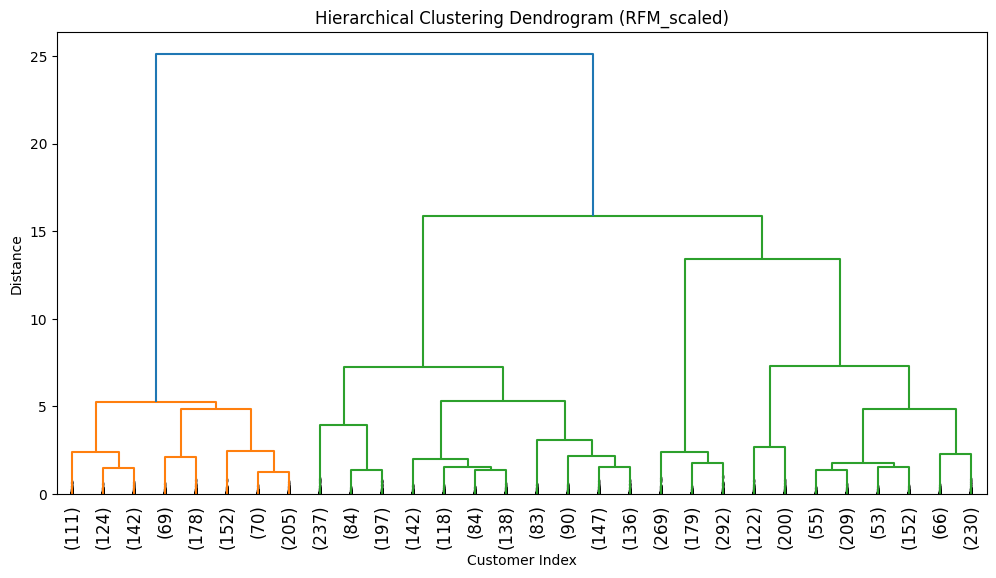

In [296]:
rfm_scaled_df_h_basic = rfm_scaled_df.copy()
linked = sch.linkage(rfm_scaled_df_h_basic, method='ward')
plt.figure(figsize=(12,6))
sch.dendrogram(linked,
               truncate_mode='lastp',
               p=30,
               leaf_rotation=90.,
               
               leaf_font_size=12.,
               show_contracted=True)
plt.title('Hierarchical Clustering Dendrogram (RFM_scaled)')
plt.xlabel('Customer Index')
plt.ylabel('Distance')
plt.show()


## Apply The Algorithm

In [297]:
K = 4

hc_rfm = AgglomerativeClustering(n_clusters=K, metric='euclidean', linkage='ward')
rfm_scaled_df_h_basic['Cluster'] = hc_rfm.fit_predict(rfm_scaled_df_h_basic)


## Silhouette Score

In [298]:

score = silhouette_score(rfm_scaled_df_h_basic.drop('Cluster', axis=1), rfm_scaled_df_h_basic['Cluster'])
print("Silhouette Score:", score)
print(rfm_scaled_df_h_basic['Cluster'].value_counts())


Silhouette Score: 0.3700136111168382
Cluster
2    1456
0    1087
1    1051
3     740
Name: count, dtype: int64


## Clusters Summary

In [299]:
for i in range(K):
    print(f"\nCluster {i} summary:")
    display(rfm_scaled_df_h_basic[rfm_scaled_df_h_basic['Cluster']==i].describe())



Cluster 0 summary:


,Recency,Frequency,Monetary,Cluster
count,1087.000000,1087.000000,1087.000000,1087.0
mean,0.454540,0.082152,0.499298,0.0
std,0.169394,0.126926,0.081501,0.0
min,0.000000,0.000000,0.052534,0.0
25%,0.352415,0.000000,0.450032,0.0
50%,0.461993,0.000000,0.503993,0.0
75%,0.584788,0.275934,0.548781,0.0
max,0.773225,0.425552,0.757349,0.0



Cluster 1 summary:


,Recency,Frequency,Monetary,Cluster
count,1051.000000,1051.000000,1051.000000,1051.0
mean,0.235034,0.680876,0.688204,1.0
std,0.135729,0.133621,0.079316,0.0
min,0.000000,0.275934,0.455774,1.0
25%,0.126879,0.587359,0.636707,1.0
50%,0.249794,0.675095,0.685000,1.0
75%,0.333704,0.785455,0.733570,1.0
max,0.539147,1.000000,1.000000,1.0



Cluster 2 summary:


,Recency,Frequency,Monetary,Cluster
count,1456.000000,1456.000000,1456.000000,1456.0
mean,0.629971,0.428513,0.594227,2.0
std,0.161373,0.136167,0.074007,0.0
min,0.290165,0.275934,0.270055,2.0
25%,0.510407,0.275934,0.550970,2.0
50%,0.612035,0.425552,0.594216,2.0
75%,0.758888,0.520807,0.644342,2.0
max,0.999282,0.915346,0.893255,2.0



Cluster 3 summary:


,Recency,Frequency,Monetary,Cluster
count,740.000000,740.0,740.000000,740.0
mean,0.897170,0.0,0.469112,3.0
std,0.070804,0.0,0.085044,0.0
min,0.700727,0.0,0.000000,3.0
25%,0.847444,0.0,0.416301,3.0
50%,0.906859,0.0,0.470453,3.0
75%,0.952188,0.0,0.515578,3.0
max,1.000000,0.0,0.927097,3.0


## Clusters Visulization

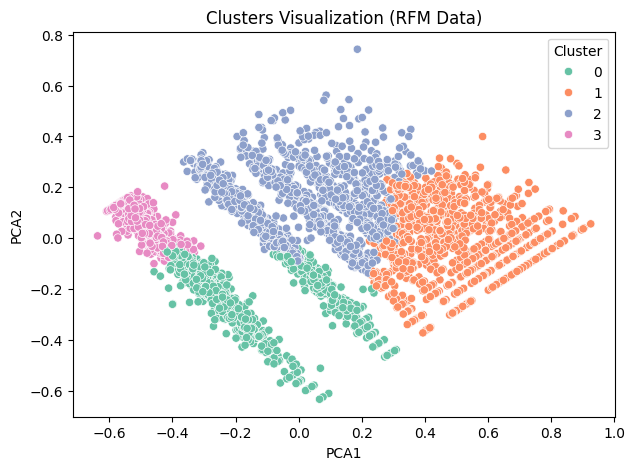

In [300]:

X = rfm_scaled_df_h_basic.drop(['Cluster'], axis=1)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X)

rfm_scaled_df_h_basic['PCA1'] = pca_result[:,0]
rfm_scaled_df_h_basic['PCA2'] = pca_result[:,1]

plt.figure(figsize=(7,5))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=rfm_scaled_df_h_basic, palette='Set2')
plt.title('Clusters Visualization (RFM Data)')
plt.show()


## Scatter Plot of Clusters

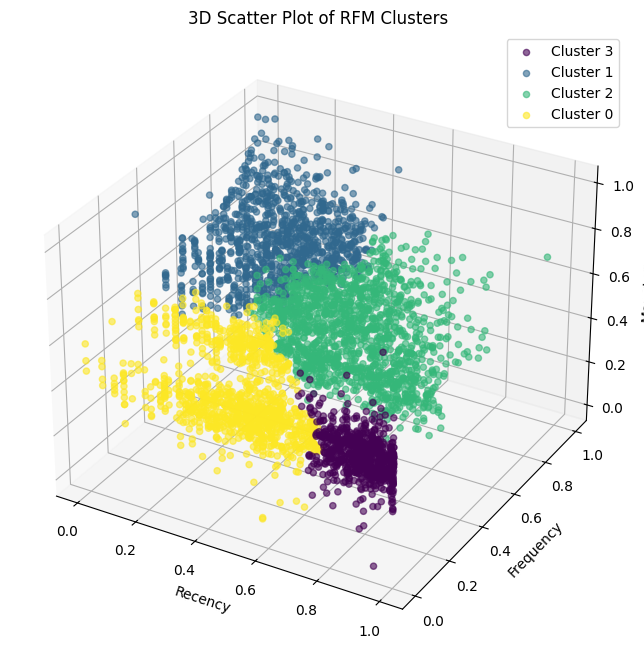

In [301]:

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

clusters = rfm_scaled_df_h_basic['Cluster'].unique()
colors = cm.viridis(np.linspace(0, 1, len(clusters)))

for cluster, color in zip(clusters, colors):
    cluster_data = rfm_scaled_df_h_basic[rfm_scaled_df_h_basic['Cluster'] == cluster]
    ax.scatter(
        cluster_data['Recency'],
        cluster_data['Frequency'],
        cluster_data['Monetary'],
        s=20,
        color=color,
        alpha=0.6,
        label=f'Cluster {cluster}'
    )

ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')
ax.set_title('3D Scatter Plot of RFM Clusters')
ax.legend()
plt.show()


# Hierarchical Clustering on PCA Data

## Dendrogram visualization

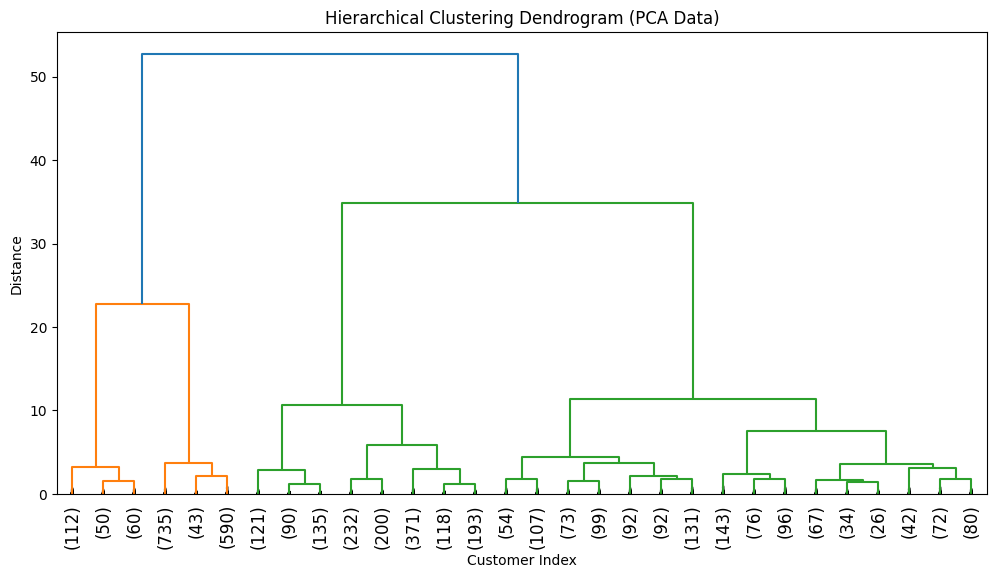

In [ ]:
pca_df_h_C = pca_df.copy()
linked = sch.linkage(pca_df_h_C, method='ward')
plt.figure(figsize=(12,6))
sch.dendrogram(linked,
               truncate_mode='lastp',
               
               p=30,     
               
               leaf_rotation=90.,
               leaf_font_size=12.,
               show_contracted=True)
plt.title('Hierarchical Clustering Dendrogram (PCA Data)')
plt.xlabel('Customer Index')
plt.ylabel('Distance')
plt.show()


# Apply The Algorithm

In [303]:

K = 4
hc_rfm = AgglomerativeClustering(n_clusters=K, metric='euclidean', linkage='ward')
pca_df_h_C['Cluster'] = hc_rfm.fit_predict(pca_df_h_C)


## Silhouette Score

In [304]:

score = silhouette_score(pca_df_h_C.drop('Cluster', axis=1), pca_df_h_C['Cluster'])
print("Silhouette Score:", score)

print(pca_df_h_C['Cluster'].value_counts())


Silhouette Score: 0.703795745540228
Cluster
2    1460
1    1368
0    1284
3     222
Name: count, dtype: int64


## Clusters Summary

In [305]:
for i in range(K):
    print(f"\nCluster {i} summary:")
    display(rfm_scaled_df_h_basic[rfm_scaled_df_h_basic['Cluster']==i].describe())



Cluster 0 summary:


,Recency,Frequency,Monetary,Cluster,PCA1,PCA2
count,1087.000000,1087.000000,1087.000000,1087.0,1087.000000,1087.000000
mean,0.454540,0.082152,0.499298,0.0,-0.150008,-0.224891
std,0.169394,0.126926,0.081501,0.0,0.180838,0.114541
min,0.000000,0.000000,0.052534,0.0,-0.458156,-0.634137
25%,0.352415,0.000000,0.450032,0.0,-0.294357,-0.297051
50%,0.461993,0.000000,0.503993,0.0,-0.208105,-0.202603
75%,0.584788,0.275934,0.548781,0.0,0.018168,-0.140253
max,0.773225,0.425552,0.757349,0.0,0.309432,-0.028677



Cluster 1 summary:


,Recency,Frequency,Monetary,Cluster,PCA1,PCA2
count,1051.000000,1051.000000,1051.000000,1051.0,1051.000000,1051.000000
mean,0.235034,0.680876,0.688204,1.0,0.476809,-0.002677
std,0.135729,0.133621,0.079316,0.0,0.145266,0.136802
min,0.000000,0.275934,0.455774,1.0,0.224663,-0.372970
25%,0.126879,0.587359,0.636707,1.0,0.355384,-0.095505
50%,0.249794,0.675095,0.685000,1.0,0.452339,-0.002829
75%,0.333704,0.785455,0.733570,1.0,0.570743,0.096880
max,0.539147,1.000000,1.000000,1.0,0.926234,0.399870



Cluster 2 summary:


,Recency,Frequency,Monetary,Cluster,PCA1,PCA2
count,1456.000000,1456.000000,1456.000000,1456.0,1456.000000,1456.000000
mean,0.629971,0.428513,0.594227,2.0,0.019635,0.136625
std,0.161373,0.136167,0.074007,0.0,0.173091,0.128852
min,0.290165,0.275934,0.270055,2.0,-0.364130,-0.137579
25%,0.510407,0.275934,0.550970,2.0,-0.112112,0.028890
50%,0.612035,0.425552,0.594216,2.0,0.027666,0.135698
75%,0.758888,0.520807,0.644342,2.0,0.165771,0.230511
max,0.999282,0.915346,0.893255,2.0,0.421262,0.743503



Cluster 3 summary:


,Recency,Frequency,Monetary,Cluster,PCA1,PCA2
count,740.000000,740.0,740.000000,740.0,740.000000,740.000000
mean,0.897170,0.0,0.469112,3.0,-0.495481,0.065330
std,0.070804,0.0,0.085044,0.0,0.050348,0.056412
min,0.700727,0.0,0.000000,3.0,-0.637359,-0.100449
25%,0.847444,0.0,0.416301,3.0,-0.535627,0.021420
50%,0.906859,0.0,0.470453,3.0,-0.499573,0.071583
75%,0.952188,0.0,0.515578,3.0,-0.463534,0.111214
max,1.000000,0.0,0.927097,3.0,-0.310017,0.204763


## Clusters Visulization

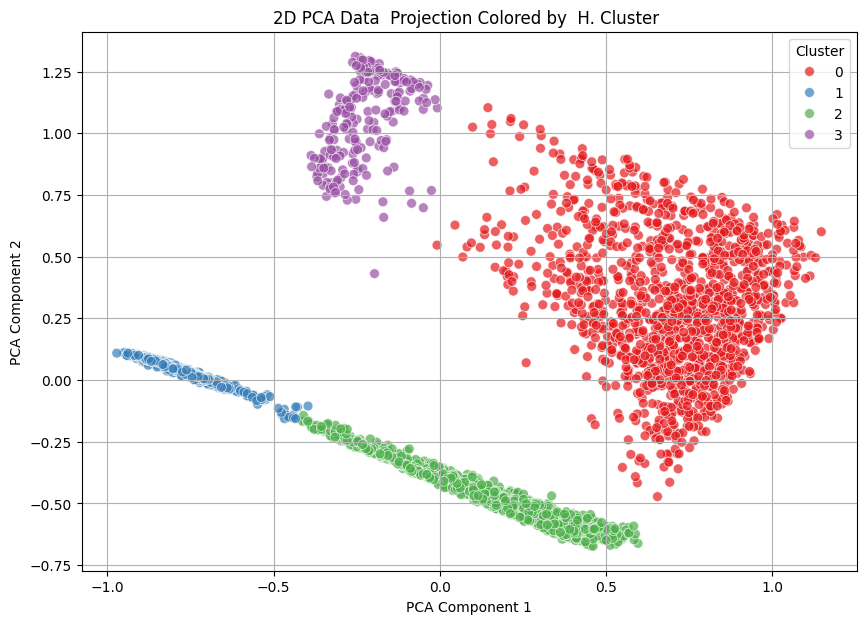

In [306]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Cluster',
    data=pca_df_h_C,
    palette='Set1',
    s=50,
    alpha=0.7
)
plt.title('2D PCA Data  Projection Colored by  H. Cluster ')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()


# Fuzzy Cmean Clustering on RFM Data

# Apply The Algorithm

In [ ]:

rfm_scaled_df_fuzzy = rfm_scaled_df.copy()
features_fcm = ['Recency', 'Frequency', 'Monetary']
X_scaled = rfm_scaled_df_fuzzy[features_fcm].values
X_fcm = X_scaled.T
K = 4
m = 2
error = 0.005
maxiter = 1000

cntr, u, u0, d, jm, p, fpc = cmeans(
 X_fcm, c=K, m=m, error=error, maxiter=maxiter, init=None
)



# Silhouette Score & Hard Labels

In [308]:
hard_labels = np.argmax(u, axis=0)
rfm_scaled_df_fuzzy['FCM_Cluster'] = hard_labels
sil_score = silhouette_score(X_scaled, hard_labels)
print(f"---   Fuzzy C-Means ---")
print(f"Silhouette Score: {sil_score:.4f}")
print(f"FPC Score: {fpc:.4f}")

---   Fuzzy C-Means ---
Silhouette Score: 0.3789
FPC Score: 0.5893


# Clusters Summary

In [309]:
rfm_features_clustered_FCM = rfm_features_PCA.copy()
rfm_features_clustered_FCM['Cluster'] = hard_labels


cluster_summary = rfm_features_clustered_FCM.groupby('Cluster')[features_fcm].mean().round(2)
cluster_summary['Count'] = rfm_features_clustered_FCM['Cluster'].value_counts().sort_index()
print("\nCluster Summary (FCM on Scaled RFM, Summarized on Original RFM):")
print(cluster_summary)




Cluster Summary (FCM on Scaled RFM, Summarized on Original RFM):
         Recency  Frequency  Monetary  Count
Cluster                                     
0         238.91       1.22    467.93   1070
1          40.16       1.25    397.79    895
2          73.58       3.66   1394.15   1337
3          11.45      10.74   5829.99   1032



# Scatter Plot of Clusters

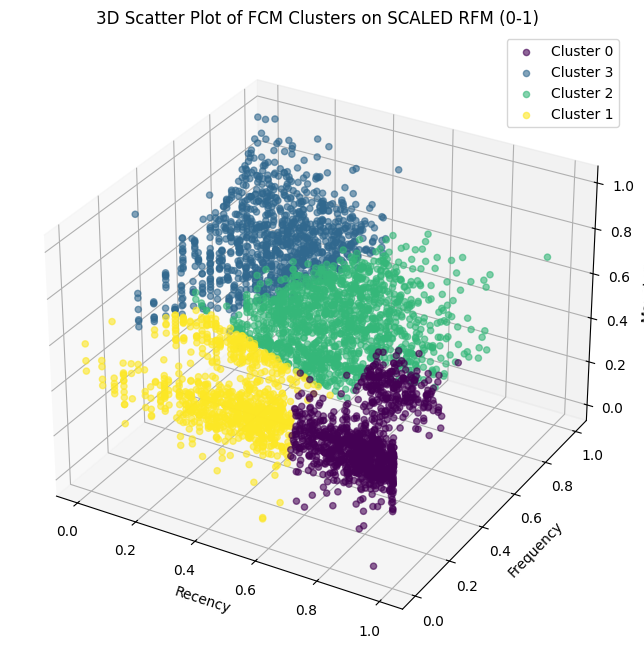

In [310]:

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

clusters = rfm_scaled_df_fuzzy['FCM_Cluster'].unique()
colors = cm.viridis(np.linspace(0, 1, len(clusters)))

for cluster, color in zip(clusters, colors):
    cluster_data = rfm_scaled_df_fuzzy[rfm_scaled_df_fuzzy['FCM_Cluster'] == cluster]
    ax.scatter(
        cluster_data['Recency'],
        cluster_data['Frequency'],
        cluster_data['Monetary'],
        s=20,
        color=color,
        alpha=0.6,
        label=f'Cluster {cluster}'
    )

ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')
ax.set_title('3D Scatter Plot of FCM Clusters on SCALED RFM (0-1)')
ax.legend()
plt.show()


# Fuzzy C Mean on PCA Data

# Apply The Algorithm

In [311]:
pca_df_PCA_fuzzy = pca_df.copy()
X_standard = pca_df_PCA_fuzzy[['PC1', 'PC2']].values
X_fcm = X_standard.T

K = 4
m = 1.1
error = 0.005
maxiter = 1000

cntr, u, u0, d, jm, p, fpc = cmeans(
    X_fcm, c=K, m=m, error=error, maxiter=maxiter, init=None
)

# Silhouette Score & Hard Labels

In [312]:
hard_labels = np.argmax(u, axis=0)
pca_df_PCA_fuzzy['FCM_Cluster'] = hard_labels
for i in range(K):
    pca_df_PCA_fuzzy[f'Membership_C{i}'] = u[i, :]

centroids = cntr.T
sil_score = silhouette_score(X_standard, hard_labels)

print(f"Silhouette Score: {sil_score:.4f}")
print(f"FPC Score (Fuzzy Partition Coefficient): {fpc:.4f}")

Silhouette Score: 0.7082
FPC Score (Fuzzy Partition Coefficient): 0.9925


# Clusters Summary


In [313]:
rfm_features_clustered_FCM = rfm_features_PCA.copy()
rfm_features_clustered_FCM['Cluster'] = hard_labels


features_to_summarize =[

    'Recency', 'Frequency', 'Monetary', 'ReturnRate',
    'Tenure', 'Avg_Days_Between_Purchases', 'Unique_Products', 'CancellationRate' 
]
cluster_summary = rfm_features_clustered_FCM.groupby('Cluster')[features_to_summarize].mean().round(2)
cluster_summary['Count'] = rfm_features_clustered_FCM['Cluster'].value_counts().sort_index()
print("\nCluster Summary:")
print(cluster_summary)



Cluster Summary:
         Recency  Frequency  Monetary  ReturnRate  Tenure  \
Cluster                                                     
0          60.49       4.41   1824.04        0.00  187.24   
1         153.42       1.09    368.14        0.00    1.53   
2         173.50       1.46   1044.11        0.12    6.65   
3          42.44       8.34   4383.56        0.03  243.42   

         Avg_Days_Between_Purchases  Unique_Products  CancellationRate  Count  
Cluster                                                                        
0                             88.98            68.44              0.00   1446  
1                              0.54            22.41              0.00   1410  
2                              2.91            25.61              0.48    269  
3                             39.62           106.52              0.25   1209  


# Scatter Plot of Clusters

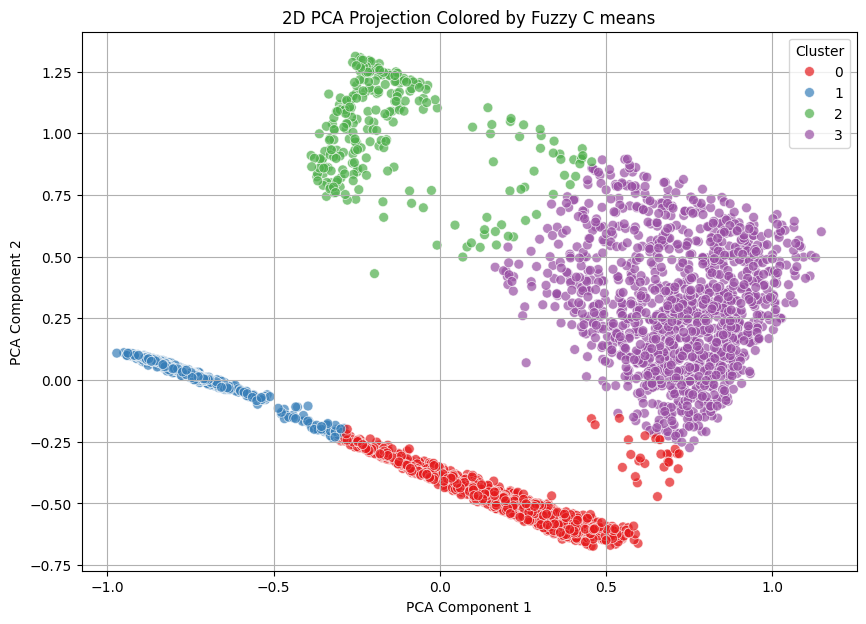

In [314]:


plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='PC1',
    y='PC2',
 hue='FCM_Cluster',
    data=pca_df_PCA_fuzzy,
    palette='Set1',
    s=50,
    alpha=0.7
)
plt.title('2D PCA Projection Colored by Fuzzy C means')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()


# DBSCAN Clustering

## DBSCAN on RFM Data

### K-Distance Graph

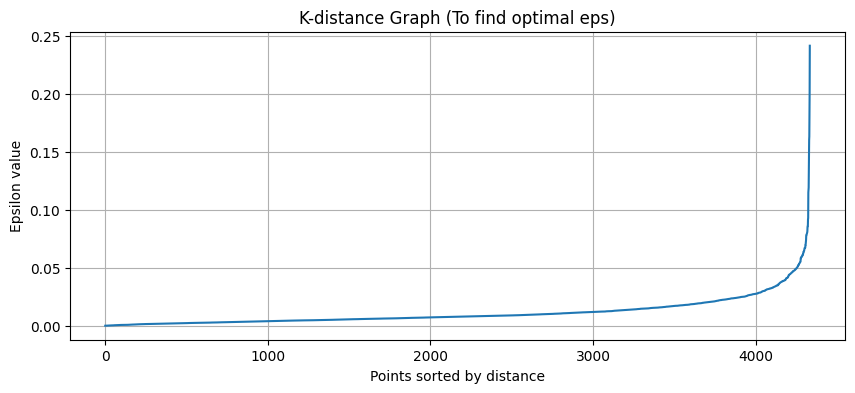

In [ ]:
neigh = NearestNeighbors(n_neighbors=10)
nbrs = neigh.fit(rfm_scaled_df)
distances, indices = nbrs.kneighbors(rfm_scaled_df)
distances = np.sort(distances[:,9], axis=0)

plt.figure(figsize=(10, 4))
plt.plot(distances)
plt.title('K-distance Graph (To find optimal eps)')
plt.xlabel('Points sorted by distance')
plt.ylabel('Epsilon value')
plt.grid(True)
plt.show()

### Applying the Algorithm

Clusters' Distribution:
Cluster_DBSCAN
 1    1495
 0    1475
 3     829
 2     496
-1      39
Name: count, dtype: int64


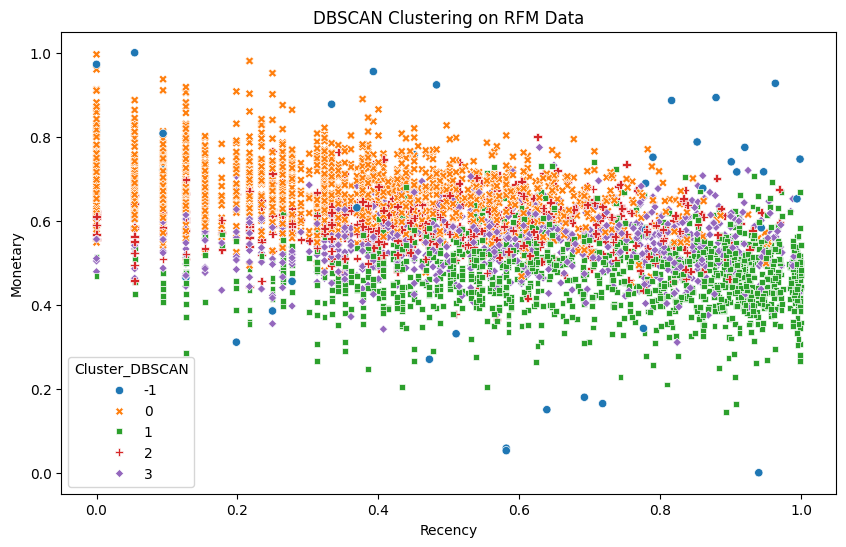

In [316]:
dbscan = DBSCAN(eps=0.09, min_samples= 10)
clustered_rfm_df_dbscan = rfm_scaled_df.copy()

clusters = dbscan.fit_predict(clustered_rfm_df_dbscan)

clustered_rfm_df_dbscan['Cluster_DBSCAN'] = clusters

print("Clusters' Distribution:")
print(clustered_rfm_df_dbscan['Cluster_DBSCAN'].value_counts())

plt.figure(figsize=(10, 6))

sns.scatterplot(data=clustered_rfm_df_dbscan, x='Recency', y='Monetary',
                hue='Cluster_DBSCAN', palette='tab10', style='Cluster_DBSCAN')
plt.title('DBSCAN Clustering on RFM Data')
plt.show()

### Cluster Evaluation

In [317]:
score = silhouette_score(rfm_scaled_df, clustered_rfm_df_dbscan['Cluster_DBSCAN'], sample_size=10000, random_state=42)

print(f"Silhouette Score: {score:.4f}")

Silhouette Score: 0.2219


## DBSCAN on PCA Data

### K-Distance Graph

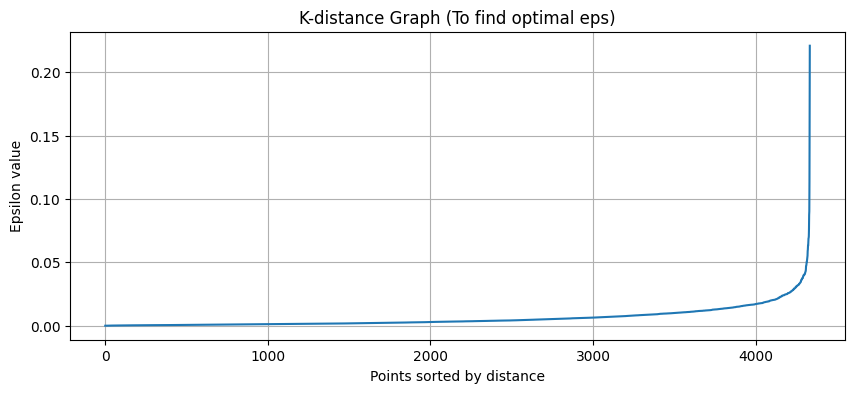

In [ ]:
neigh = NearestNeighbors(n_neighbors=10)
nbrs = neigh.fit(pca_df)
distances, indices = nbrs.kneighbors(pca_df)
distances = np.sort(distances[:,9], axis=0)

plt.figure(figsize=(10, 4))
plt.plot(distances)
plt.title('K-distance Graph (To find optimal eps)')
plt.xlabel('Points sorted by distance')
plt.ylabel('Epsilon value')
plt.grid(True)
plt.show()

### Applying the Algorithm

Clusters' Distribution:
Cluster_DBSCAN
 1    2828
 2    1263
 0     216
-1      27
Name: count, dtype: int64


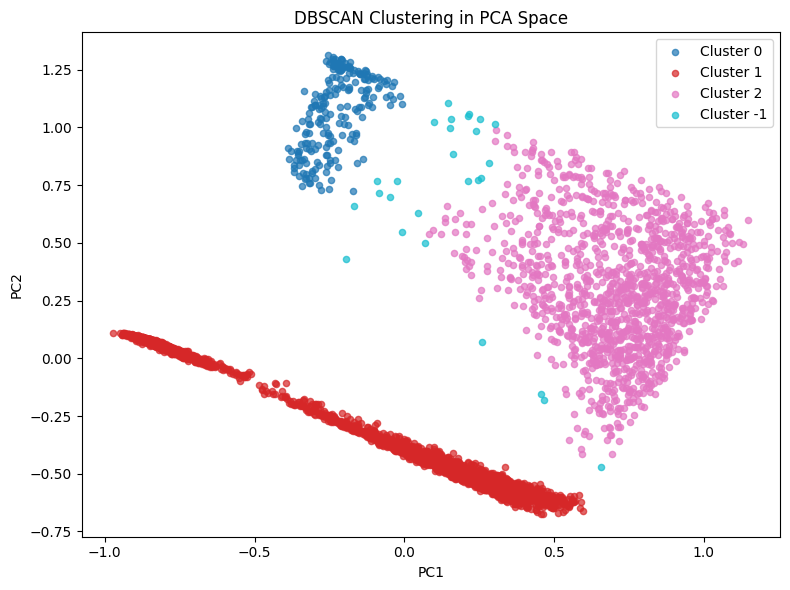

In [319]:
dbscan = DBSCAN(eps=0.09, min_samples= 10)
clustered_rfm_df_dbscan = pca_df.copy()

clusters = dbscan.fit_predict(clustered_rfm_df_dbscan)

clustered_rfm_df_dbscan['Cluster_DBSCAN'] = clusters

print("Clusters' Distribution:")
print(clustered_rfm_df_dbscan['Cluster_DBSCAN'].value_counts())

clustered_rfm_df_dbscan['Cluster_DBSCAN'] = clustered_rfm_df_dbscan['Cluster_DBSCAN'].astype(str)

plt.figure(figsize=(8,6))


clusters = clustered_rfm_df_dbscan['Cluster_DBSCAN'].unique()
colors = cm.tab10(np.linspace(0, 1, len(clusters)))  
for cluster, color in zip(clusters, colors):
    cluster_data = clustered_rfm_df_dbscan[clustered_rfm_df_dbscan['Cluster_DBSCAN'] == cluster]
    plt.scatter(
        cluster_data['PC1'],
        cluster_data['PC2'],
        s=20,          
        color=color,
        alpha=0.7,
        label=f'Cluster {cluster}'
    )

plt.title('DBSCAN Clustering in PCA Space')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.tight_layout()
plt.show()


### Cluster Evaluation

In [320]:
data = pca_df.copy().to_numpy()
labels = clustered_rfm_df_dbscan['Cluster_DBSCAN'].astype(int).to_numpy()

dbcv_score = hdbscan.validity.validity_index(data, labels)

print(f"DBCV Score for DBSCAN: {dbcv_score:.4f}")

DBCV Score for DBSCAN: 0.4735


# Cluster Understanding

# RFM With Cluster Results

In [321]:
rfm_features_PCA_dbscan = rfm_features_PCA.copy()

rfm_features_PCA_dbscan['Cluster_DBSCAN'] = clustered_rfm_df_dbscan['Cluster_DBSCAN'].values

rfm_features_PCA_dbscan.head()
rfm_features_PCA_dbscan['Cluster_DBSCAN'].value_counts()

Cluster_DBSCAN
1     2828
2     1263
0      216
-1      27
Name: count, dtype: int64

# Cluster Profile

In [322]:
cluster_profile = rfm_features_PCA_dbscan.groupby('Cluster_DBSCAN').mean()
cluster_profile

,CustomerID,Recency,Frequency,Monetary,ReturnRate,Tenure,Avg_Days_Between_Purchases,Unique_Products,CancellationRate
Cluster_DBSCAN,,,,,,,,,
-1,15119.592593,185.555556,7.555556,11853.205926,0.125489,48.814815,6.946468,52.740741,0.325826
0,15123.527778,173.115741,1.064815,1058.566898,0.122507,1.046296,0.938272,24.129630,0.508642
1,15351.736917,107.271570,2.538897,940.448091,0.000000,93.237270,45.608562,44.151697,0.000000
2,15215.624703,44.345210,8.541568,4377.635338,0.034592,240.519398,38.586770,106.672209,0.253202


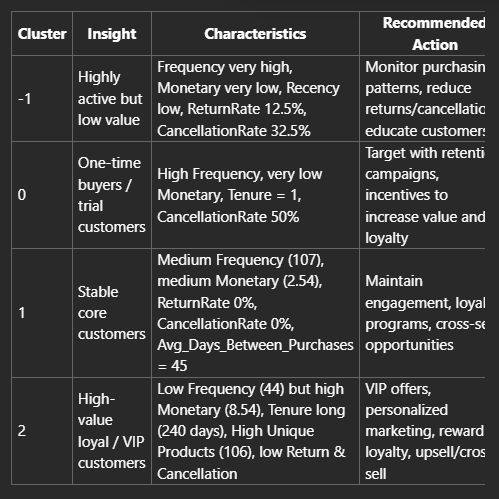